C:\Users\Admin\AppData\Local\Temp\ipykernel_17548\2976921695.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(
[*********************100%***********************]  3 of 3 completed


Ticker      HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS
Date                                               
2024-01-01   826.441040    983.282715    380.972717
2024-01-02   826.927734    966.409302    372.172516
2024-01-03   814.176575    968.180237    372.342133
2024-01-04   822.912537    971.230286    371.883179
2024-01-05   818.702698    977.674622    368.690338
...                 ...           ...           ...
2024-12-24   887.059631   1287.317017    349.407135
2024-12-26   883.433655   1287.416138    350.156281
2024-12-27   887.133667   1297.538208    351.574677
2024-12-30   877.094360   1284.736938    347.739075
2024-12-31   874.603027   1271.836426    356.798615

[246 rows x 3 columns]
Ticker      HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS
Date                                               
2024-01-01   826.441040    983.282715    380.972717
2024-01-02   826.927734    966.409302    372.172516
2024-01-03   814.176575    968.180237    372.342133
Shape: (246, 3)
Ticker      HDFCBANK.NS 

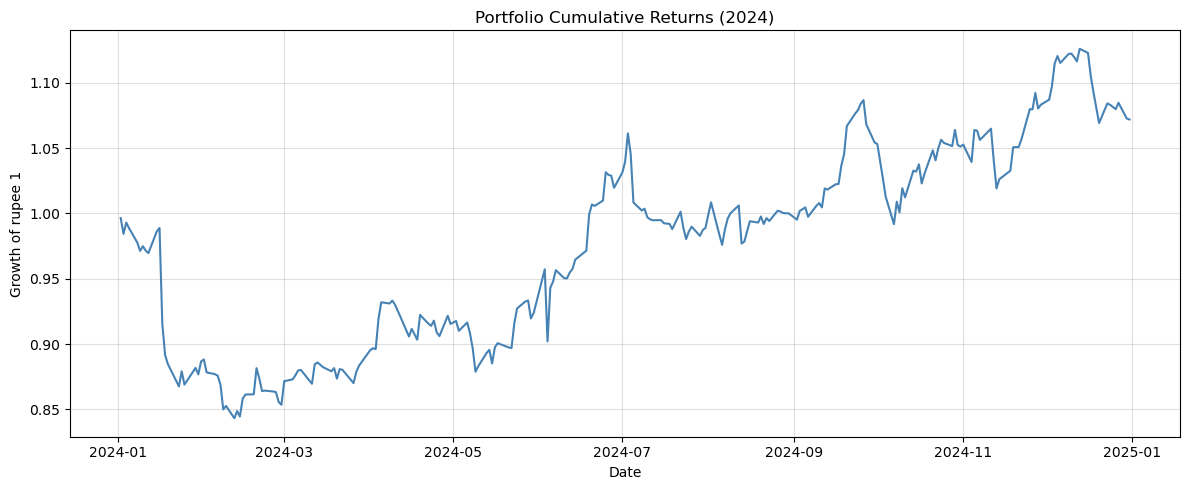

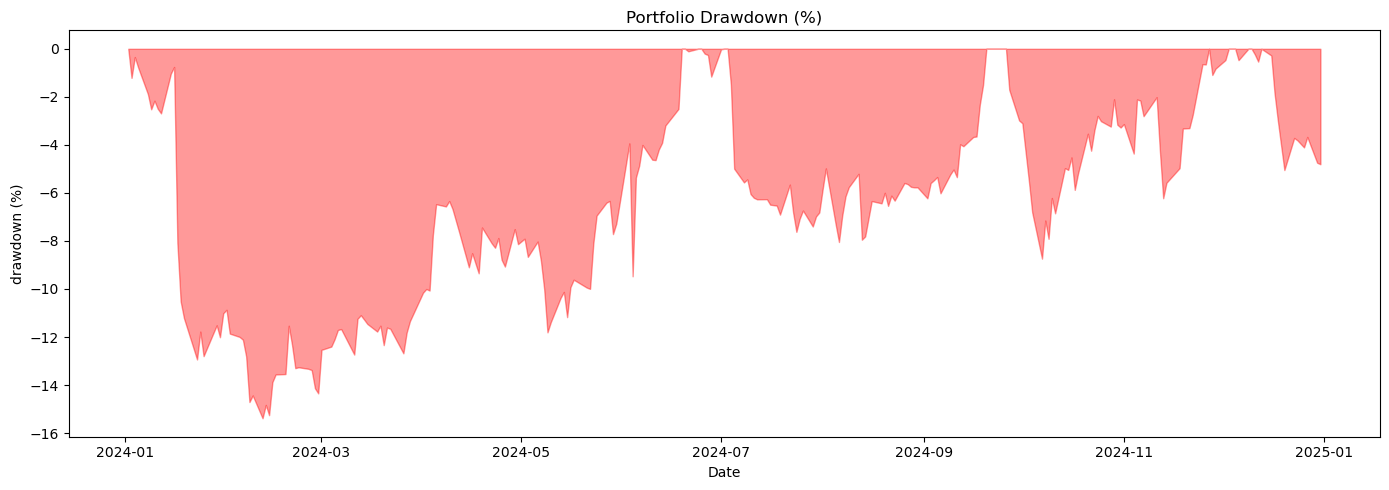


Max Drawdown: -15.38%

=== Optimal Portfolio Weights ===
HDFCBANK     0.003179
ICICIBANK    0.990554
KOTAKBANK    0.006267
Sharpe       1.080665
Name: 6144, dtype: float64


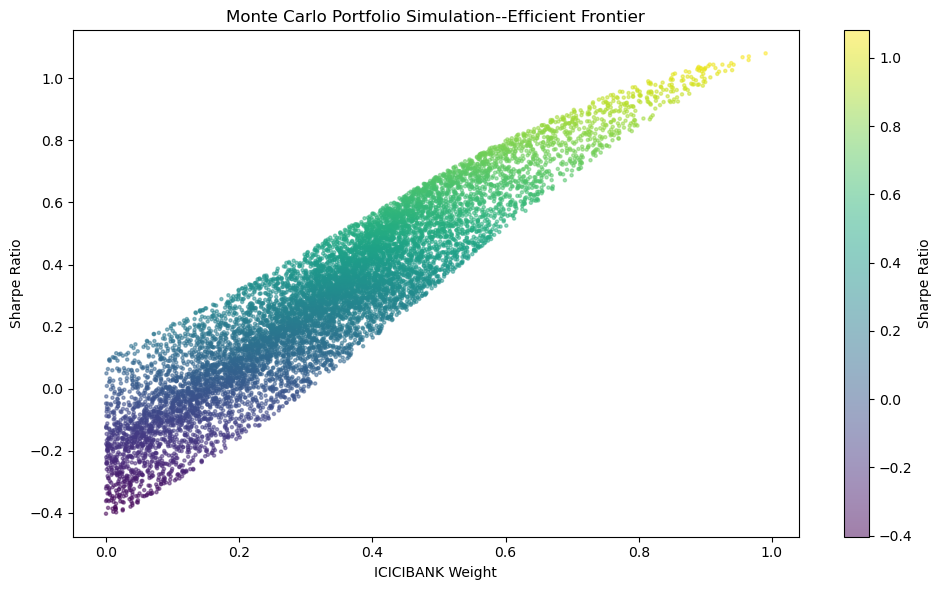

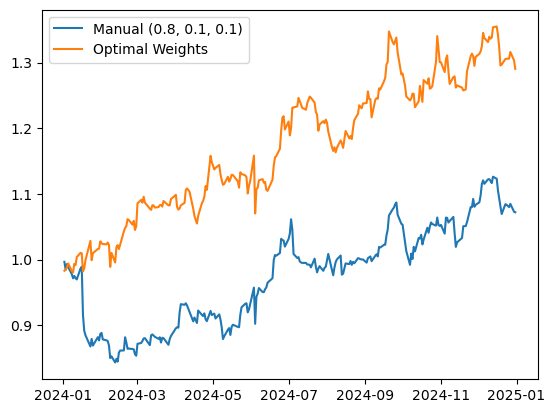

In [59]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=yf.download(
    ["HDFCBANK.NS", "ICICIBANK.NS","KOTAKBANK.NS"],
    start="2024-01-01",
    end="2025-01-01"
)
prices=data["Close"]
print(prices)
print(prices.head(3))
print("Shape:",prices.shape)
returns=prices.pct_change(fill_method=None)
returns=returns.dropna()
print(returns.head(3))
print("Returns:",returns.shape)

def sharpe_ratio(returns, risk_free=0.06):
    daily_rf=risk_free/252
    excess_return=(returns.mean()-daily_rf)/returns.std()
    sharpe=excess_return*np.sqrt(252)
    return sharpe

individual_sharpe=sharpe_ratio(returns)
print("\n===Individual Sharpe ratio===")
print(individual_sharpe)

weights=[0.8,0.1,0.1]
portfolio_returns=returns@ weights

print("\n=== Portfolio Sharpe Ratio ===")
print(sharpe_ratio(portfolio_returns))

cumulative=(1+portfolio_returns).cumprod()

plt.figure(figsize=(12,5))
plt.plot(cumulative, color="steelblue", linewidth=1.5)
plt.title("Portfolio Cumulative Returns (2024)")
plt.xlabel("Date")
plt.ylabel("Growth of rupee 1")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

pv=cumulative
peak=pv.cummax()
drawdown=(pv-peak)/peak*100

fid, ax=plt.subplots(figsize=(14,5))
ax.fill_between(drawdown.index, drawdown.values, 0, color="red", alpha=0.4)
ax.set_title("Portfolio Drawdown (%)")
ax.set_ylabel("drawdown (%)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

print(f"\nMax Drawdown: {drawdown.min():.2f}%")

results=[]
for i in range(10000):
    w=np.random.random(3)
    w=w/w.sum()
    port_ret=returns @ w
    sharpe=sharpe_ratio(port_ret)
    results.append([w[0], w[1], w[2], sharpe])

df=pd.DataFrame(results, columns=["HDFCBANK", "ICICIBANK", "KOTAKBANK", "Sharpe"])

best=df.loc[df["Sharpe"].idxmax()]
print("\n=== Optimal Portfolio Weights ===")
print(best)

plt.figure(figsize=(10, 6))
plt.scatter(
    df["ICICIBANK"],
    df["Sharpe"],
    c=df["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=5
)

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("ICICIBANK Weight")
plt.ylabel("Sharpe Ratio")
plt.title("Monte Carlo Portfolio Simulation--Efficient Frontier")
plt.tight_layout()
plt.show()

optimal_weights = best[["HDFCBANK", "ICICIBANK", "KOTAKBANK"]].values

optimal_port_ret = returns @ optimal_weights

cumulative_optimal = (1 + optimal_port_ret).cumprod()

plt.plot(cumulative, label="Manual (0.8, 0.1, 0.1)")
plt.plot(cumulative_optimal, label="Optimal Weights")
plt.legend()





